In [149]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import matplotlib.pyplot as plt
import seaborn as sn
import emoji

In [150]:
df = pd.read_csv('../data/features/youtube_features.csv')


In [151]:
def get_plain_text(text):
    text = str(text)
    text = re.sub(r'http\S+|wwww\S+', '', text)
    text = ''.join(ch for ch in text if ch.isalnum() or ch.isspace() or ch in emoji.EMOJI_DATA)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [152]:
df['title_cleaned'] = df['title'].apply(get_plain_text)

In [153]:
tfidf = TfidfVectorizer(max_features=50,
                        stop_words='english',
                        ngram_range=(1, 2), 
                        min_df = 2,
                        max_df = .8
                        )

In [154]:
tfidf_matrix = tfidf.fit_transform(df['title_cleaned'])

In [155]:
feature_names = tfidf.get_feature_names_out()
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"\nTop 50 features extracted:")
print(feature_names)

TF-IDF matrix shape: (55886, 50)

Top 50 features extracted:
['10' '2017' '2018' 'au' 'avec' 'best' 'dans' 'des' 'du' 'dã' 'en' 'ep'
 'episode' 'est' 'et' 'france' 'ft' 'game' 'hd' 'highlights' 'je' 'johnny'
 'la' 'le' 'les' 'live' 'music' 'new' 'official' 'pas' 'plus' 'pour' 'qui'
 'rã' 'season' 'son' 'sur' 'trailer' 'trump' 'tv' 'une' 'video' 'vs' 'ðÿ'
 'øø' 'øùøùùø' 'ùø³ùø³ù' 'ùù' 'ùùš' 'ùˆ']


In [156]:
# too much french words in the titles 
# we should try to filter out for better results


from langdetect import LangDetectException, detect

def is_english(text):
    text = str(text).strip()
    if not text or len(text.split()) < 2:
        return False
    try:
        return detect(text) == 'en'
    except LangDetectException:
        return False


In [157]:
df = df[df['title_cleaned'].apply(is_english)]
df = df.reset_index(drop=True)

In [158]:
tfidf_matrix = tfidf.fit_transform(df['title_cleaned'])
feature_names = tfidf.get_feature_names_out()

print(f"Filtered dataset shape: {df.shape}")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"\nTop 50 features extracted:\n{feature_names}")

Filtered dataset shape: (26601, 26)
TF-IDF matrix shape: (26601, 50)

Top 50 features extracted:
['10' '2017' '2018' 'audio' 'best' 'black' 'challenge' 'christmas' 'clip'
 'clip officiel' 'day' 'en' 'ep' 'episode' 'et' 'feat' 'food' 'ft' 'game'
 'game highlights' 'goals' 'hd' 'highlights' 'house' 'joe' 'la' 'le'
 'live' 'love' 'movie' 'music' 'nba' 'new' 'news' 'official'
 'official trailer' 'official video' 'officiel' 'real' 'season' 'songs'
 'star' 'time' 'trailer' 'trump' 'tv' 'video' 'vs' 'world' 'ðÿ']


Top 20 most important words:
          word  avg_tfidf
2         2018   0.069466
47          vs   0.032109
44       trump   0.026814
1         2017   0.025620
32         new   0.022805
13     episode   0.021426
34    official   0.021351
46       video   0.021265
18        game   0.019847
27        live   0.018289
25          la   0.016872
0           10   0.016534
17          ft   0.016192
22  highlights   0.015663
43     trailer   0.014953
21          hd   0.014858
26          le   0.014606
39      season   0.014108
4         best   0.013245
6    challenge   0.013047


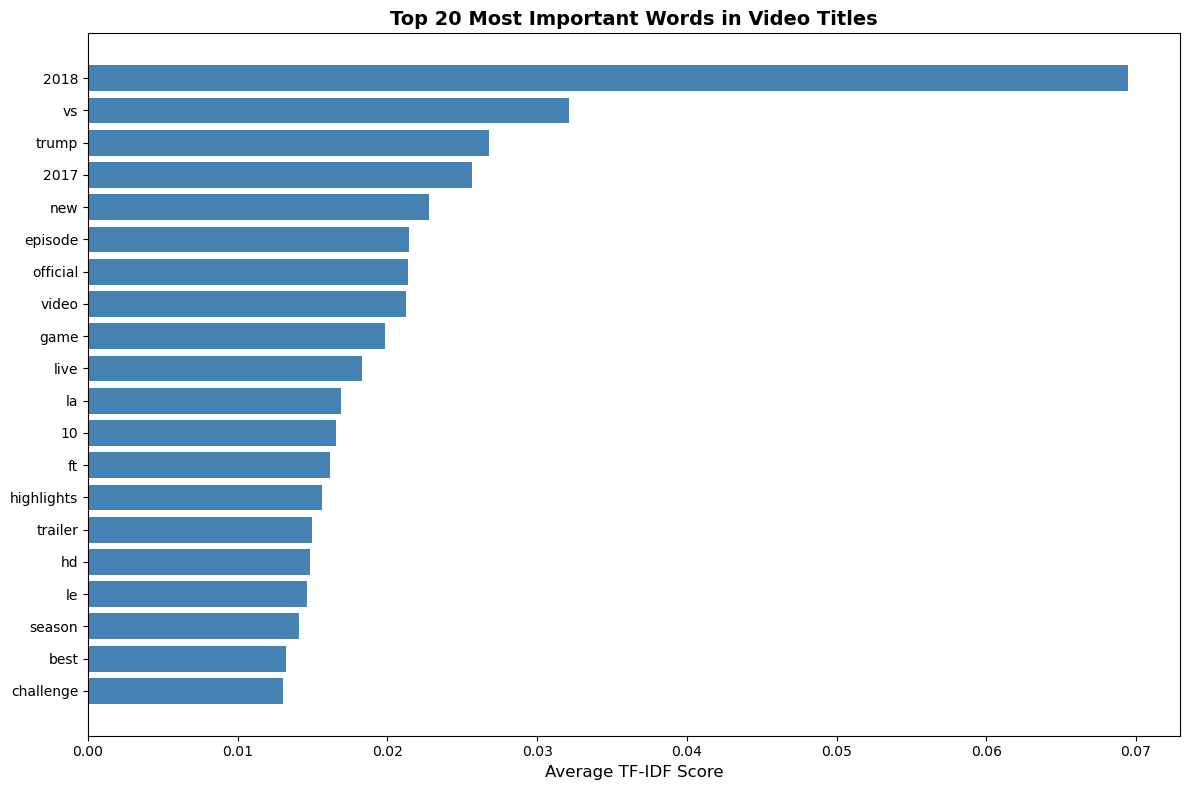

In [159]:
word_importance = tfidf_matrix.mean(axis=0).A1
word_importance_df = pd.DataFrame({
    'word': feature_names,
    'avg_tfidf': word_importance
}).sort_values('avg_tfidf', ascending=False)

print("Top 20 most important words:")
print(word_importance_df.head(20))


plt.figure(figsize=(12, 8))
top_20 = word_importance_df.head(20)
plt.barh(range(len(top_20)), top_20['avg_tfidf'], color='steelblue')
plt.yticks(range(len(top_20)), top_20['word'])
plt.xlabel('Average TF-IDF Score', fontsize=12)
plt.title('Top 20 Most Important Words in Video Titles', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/tfidf_top_words.png', dpi=300, bbox_inches='tight')
plt.show()

In [160]:
from collections import Counter
def extract_emojis(text):
    return [ch for ch in text if ch in emoji.EMOJI_DATA]

# Flatten all emojis into one list
all_emojis = [em for text in df['title_cleaned'] for em in extract_emojis(text)]

# Count top emojis
emoji_counts = Counter(all_emojis).most_common(20)

print("🎉 Top Emojis Used:")
for e, count in emoji_counts:
    print(f"{e}  →  {count} times")


🎉 Top Emojis Used:
©  →  1154 times
™  →  916 times
®  →  107 times


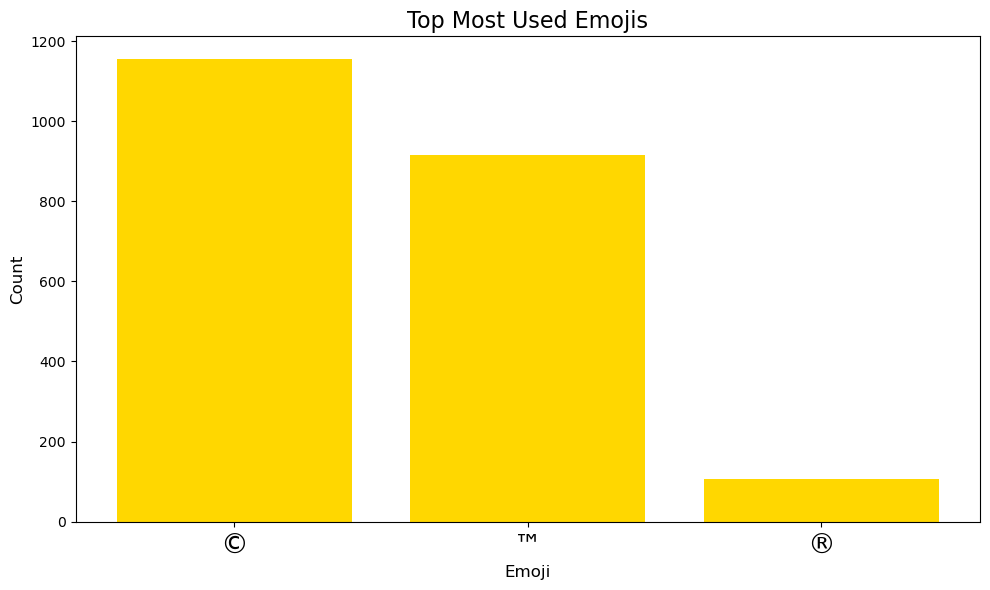

In [161]:
if emoji_counts:
    emojis, counts = zip(*emoji_counts)

    plt.figure(figsize=(10, 6))
    bars = plt.bar(emojis, counts, color='gold')

    plt.title("Top Most Used Emojis", fontsize=16)
    plt.xlabel("Emoji", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("No emojis found in dataset.")